# Python template Plot Graph
- seabornでどんなグラフが描画できるのかを視覚的に把握しやすいように、だいたい使いそうなのを作ってみた
- あくまでグラフのサンプルを作るのが目的


In [ ]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
# from prophet import Prophet
# import pymc as pm
# import arviz as az

import sklearn

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
# import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

print("scikit-learn", sklearn.__version__)

Created(JST) 2026-03-20 14:30:07
Python v3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:52:34) [Clang 18.1.8 ]
pandas 2.2.0
numpy 1.26.4
matplotlib 3.10.5
seaborn 0.13.2


# read data

In [2]:
# # 乱数の固定
# np.random.seed(42)

# # データの生成
# n_rows = 200
# weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# menu = ['Coffee', 'Tea', 'Cake', 'Sandwich']
# sections = ['Indoor', 'Terrace']

# df = pd.DataFrame({
#     'date': np.random.choice(pd.date_range('2025-07-01', periods=7), n_rows),
#     'weekday': np.random.choice(weekdays, n_rows),
#     'menu': np.random.choice(menu, n_rows),
#     'section': np.random.choice(sections, n_rows),
#     'price': np.random.randint(400, 1200, n_rows),
#     'customer_age': np.random.normal(35, 12, n_rows).clip(18, 70), # 18歳〜70歳
#     'satisfaction': np.random.uniform(1, 5, n_rows) # 5段階評価
# })

# # 曜日を並び替え可能にする
# df['weekday'] = pd.Categorical(df['weekday'], categories=weekdays, ordered=True)

In [3]:
# # サンプルのdataframeを生成する

# # 乱数の固定
# np.random.seed(42)

# # データの生成
# n_rows = 200
# weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# menu = ['Coffee', 'Tea', 'Cake', 'Sandwich']
# sections = ['Indoor', 'Terrace']


# import string

# # --- ID生成のロジック ---
# # 1. まずは「顧客名簿（ユニークなIDのストック）」を50人分だけ作る
# n_customers = 50 
# # 使用する文字（英小文字 + 数字）を定義
# chars = string.ascii_lowercase + string.digits
# # 8桁の文字列をn_rows分だけ作成
# customer_pool = [''.join(np.random.choice(list(chars), 8)) for _ in range(n_customers)]

# # 2. 全200件のレコードに対して、名簿からランダムにIDを割り当てる（重複あり）
# customer_ids = np.random.choice(customer_pool, n_rows, replace=True)


# df = pd.DataFrame({
#     'customer_id': customer_ids, # これでリピーターが発生する
#     'date': np.random.choice(pd.date_range('2025-07-01', periods=7), n_rows),
#     'weekday': np.random.choice(weekdays, n_rows),
#     'menu': np.random.choice(menu, n_rows),
#     'section': np.random.choice(sections, n_rows),
#     'price': np.random.randint(400, 1200, n_rows),
#     'customer_age': np.random.normal(35, 12, n_rows).clip(18, 70),
#     'satisfaction': np.random.uniform(1, 5, n_rows)
# })

# # 曜日の並び順を指定
# df['weekday'] = pd.Categorical(df['weekday'], categories=weekdays, ordered=True)

# # menuの順序を指定
# df["menu"] = pd.Categorical(df["menu"], categories=menu, ordered=True)

In [4]:
# サンプルのdataframeを生成する

import string

# 乱数の固定
np.random.seed(42)

# 基本設定
n_rows = 200
n_customers = 50 
weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
menu = ['Coffee', 'Tea', 'Cake', 'Sandwich']
sections = ['Indoor', 'Terrace']
genders = ['Male', 'Female', 'Other']

# 1. 【マスター作成】50人分のユニークな属性を決めてしまう
chars = string.ascii_lowercase + string.digits
customer_pool = [''.join(np.random.choice(list(chars), 8)) for _ in range(n_customers)]

customer_master = pd.DataFrame({
    'customer_id': customer_pool,
    'customer_gender': np.random.choice(genders, n_customers),
    'customer_age': np.random.normal(35, 12, n_customers).clip(18, 70).astype(int)
})

# 2. 【履歴作成】200行分の「誰がいつ何をしたか」の枠組みを作る
df = pd.DataFrame({
    'customer_id': np.random.choice(customer_pool, n_rows, replace=True),
    'date': np.random.choice(pd.date_range('2025-07-01', periods=7), n_rows),
    'menu': np.random.choice(menu, n_rows),
    'section': np.random.choice(sections, n_rows),
    'price': np.random.randint(400, 1200, n_rows),
    'satisfaction': np.random.uniform(1, 5, n_rows)
})

# 3. 【結合】IDをキーにしてマスターの属性をドッキングさせる
df = pd.merge(df, customer_master, on='customer_id', how='left')

# 仕上げ：順序や型を整える
df['weekday'] = df['date'].dt.strftime('%a') # 日付から自動で曜日を生成
df['weekday'] = pd.Categorical(df['weekday'], categories=weekdays, ordered=True)
df['menu'] = pd.Categorical(df['menu'], categories=menu, ordered=True)

In [5]:
print(df.head())

  customer_id       date    menu  section  price  satisfaction  \
0    esd8q132 2025-07-05  Coffee   Indoor   1106      2.359500   
1    mg9tahpn 2025-07-05  Coffee   Indoor    870      3.899067   
2    h8nq9dbf 2025-07-02  Coffee  Terrace    518      1.261425   
3    pev2clzp 2025-07-04    Cake  Terrace    795      2.261161   
4    v2n1e3el 2025-07-02    Cake  Terrace    931      3.157965   

  customer_gender  customer_age weekday  
0           Other            18     Sat  
1           Other            18     Sat  
2          Female            33     Wed  
3            Male            41     Fri  
4           Other            45     Wed  


In [6]:
print(df.head())
print(df.tail())
print(df.info())

  customer_id       date    menu  section  price  satisfaction  \
0    esd8q132 2025-07-05  Coffee   Indoor   1106      2.359500   
1    mg9tahpn 2025-07-05  Coffee   Indoor    870      3.899067   
2    h8nq9dbf 2025-07-02  Coffee  Terrace    518      1.261425   
3    pev2clzp 2025-07-04    Cake  Terrace    795      2.261161   
4    v2n1e3el 2025-07-02    Cake  Terrace    931      3.157965   

  customer_gender  customer_age weekday  
0           Other            18     Sat  
1           Other            18     Sat  
2          Female            33     Wed  
3            Male            41     Fri  
4           Other            45     Wed  
    customer_id       date    menu  section  price  satisfaction  \
195    i8spctx6 2025-07-02     Tea  Terrace   1019      1.919818   
196    y2rrb8p9 2025-07-04    Cake   Indoor    587      1.852419   
197    007u3616 2025-07-01    Cake  Terrace    497      1.124536   
198    lca6j2ml 2025-07-07  Coffee   Indoor    530      3.606667   
199    o55x

# data check

In [7]:
# 列ごとに欠損値がいくつあるか
print(df.isnull().sum())

# 欠損値の割合で見たい場合
print(df.isnull().mean() * 100)

customer_id        0
date               0
menu               0
section            0
price              0
satisfaction       0
customer_gender    0
customer_age       0
weekday            0
dtype: int64
customer_id        0.0
date               0.0
menu               0.0
section            0.0
price              0.0
satisfaction       0.0
customer_gender    0.0
customer_age       0.0
weekday            0.0
dtype: float64


In [8]:
# 数値データのみを対象にする
print(df.describe())

                      date        price  satisfaction  customer_age
count                  200   200.000000    200.000000    200.000000
mean   2025-07-04 02:24:00   787.730000      3.108582     33.760000
min    2025-07-01 00:00:00   403.000000      1.025543     18.000000
25%    2025-07-02 00:00:00   564.750000      2.056604     24.000000
50%    2025-07-04 00:00:00   783.500000      3.184248     34.000000
75%    2025-07-06 00:00:00  1000.750000      4.149758     40.000000
max    2025-07-07 00:00:00  1193.000000      4.991736     70.000000
std                    NaN   239.392084      1.193937     11.577677


In [9]:
# 「数値以外（カテゴリデータなど）」の要約（頻度やユニーク数）も見たい場合
df.describe(exclude='number')

,customer_id,date,menu,section,customer_gender,weekday
count,200,200,200,200,200,200
unique,49,NaN,4,2,3,7
top,ynizbt1g,NaN,Cake,Indoor,Male,Sun
freq,7,NaN,53,110,85,36
mean,NaN,2025-07-04 02:24:00,NaN,NaN,NaN,NaN
min,NaN,2025-07-01 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,2025-07-02 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,2025-07-04 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,2025-07-06 00:00:00,NaN,NaN,NaN,NaN
max,NaN,2025-07-07 00:00:00,NaN,NaN,NaN,NaN


In [10]:
# 特定の列（例：menu）のユニークな値
print(df['menu'].unique())

# それぞれの出現回数（多い順に）
print(df['menu'].value_counts())

['Coffee', 'Cake', 'Sandwich', 'Tea']
Categories (4, object): ['Coffee' < 'Tea' < 'Cake' < 'Sandwich']
menu
Cake        53
Coffee      51
Sandwich    49
Tea         47
Name: count, dtype: int64


In [11]:
# 特定の列のユニークな値
print(df['section'].unique())

# それぞれの出現回数（多い順に）
print(df['section'].value_counts())

['Indoor' 'Terrace']
section
Indoor     110
Terrace     90
Name: count, dtype: int64


In [12]:
# 特定の列のユニークな値
print(df['customer_gender'].unique())

# それぞれの出現回数（多い順に）
print(df['customer_gender'].value_counts())

['Other' 'Female' 'Male']
customer_gender
Male      85
Other     59
Female    56
Name: count, dtype: int64


In [13]:
# 特定の列のユニークな値の数
print(df['customer_id'].nunique())

# それぞれの出現回数（多い順に）
print(df['customer_id'].value_counts())

49
customer_id
ynizbt1g    7
t3k1y6a0    7
xkh9t8y8    7
f8x2486u    7
007u3616    6
je974js5    6
bz5f5dkq    6
886e1gih    6
ixahxkqh    6
mg9tahpn    6
2ohuswkk    6
lca6j2ml    5
8a8ncaez    5
4ohnwupr    5
bu6lvy01    5
esd8q132    5
6d6nuthg    5
q6i2z8yx    5
5gv1bf11    5
mcfh0i6x    4
50txl866    4
5d3wo29m    4
cq6lvv3h    4
ifp2ct9s    4
aedpxpb1    4
v2n1e3el    4
pocguird    4
h8nq9dbf    4
i8spctx6    4
y2rrb8p9    3
ak1yw438    3
x9xcvbx3    3
l76wx8v0    3
gpzbale5    3
zcst5g6r    3
n0ioozm5    3
edf538pm    3
bb1w56as    3
o55xlbcq    3
5w6cry4c    3
x5vwb0bz    3
xzy2oayg    2
pzzu963w    2
pev2clzp    2
vyvvfo6h    2
lwo17b5w    2
ilaa75ya    2
xe7fvkp6    1
3sqs1zzw    1
Name: count, dtype: int64


In [14]:
# objectになった日付データを日付型に
# 曜日カラムの作成
# カテゴリ変数の並び順を指定

# 前処理
## matplotlibで日本語表示できるようにする

In [15]:
# plt.rcParams["font.family"] = ["sans-serif", "Meiryo"]  # windows用
plt.rcParams["font.family"] = ["sans-serif", "Hiragino Sans"]  # mac用

# plt.rcParams["font.family"] = ["Hiragino Sans", "Meiryo", "sans-serif"]  # windowsとmac両対応


# 色の指定 colormap cmap
# df.plot(kind="line", x="date", y="value", figsize=(10, 5), colormap="Pastel1")
# # ただしこれだと区分に応じてpastel1をリストの数で分割して色配分される。つまり5区分と6区分で色の配分が変わる。
# # そういう時は自分で色を指定する
# color_list = ["#fbb4ae", "#b3cde3", "#ccebc5", "#decbe4", "#fed9a6", "#ffffcc"]
# hogehoge.plot(kind="line", x="date", y="value", figsize=(10, 5), color=color_list)

# seaborn
seabornにはfigure-level関数と、axis-level関数がある

figure-level関数は、グラフ全体を管理する関数で、複数のグラフを一度に描画できる。
- displot
- relplot
- catplot

引数kindでグラフ種別を指定する、それぞれに対応するaxis-level関数がある

- figure-levelのメリット
  - hueだけでなくcol, row, col_wrapなどを駆使して、複数のサププロットを同一スケールで一意に見やすい
  - サイズ指定はheight, aspectで簡単
  - x軸y軸の線のみで枠囲みがないぶんデータが際立ちやすい
- figure-levelのデメリット
  - 細かいカスタマイズが難しい
  - なのでざっとEDA的に見たいとき用
- 逆にaxis-levelが生きる時
  - 表現の柔軟性に優れる
  - hueが使えなくても重ねて表示すればいい

# 複数グラフ

## figure-levelで複数グラフ

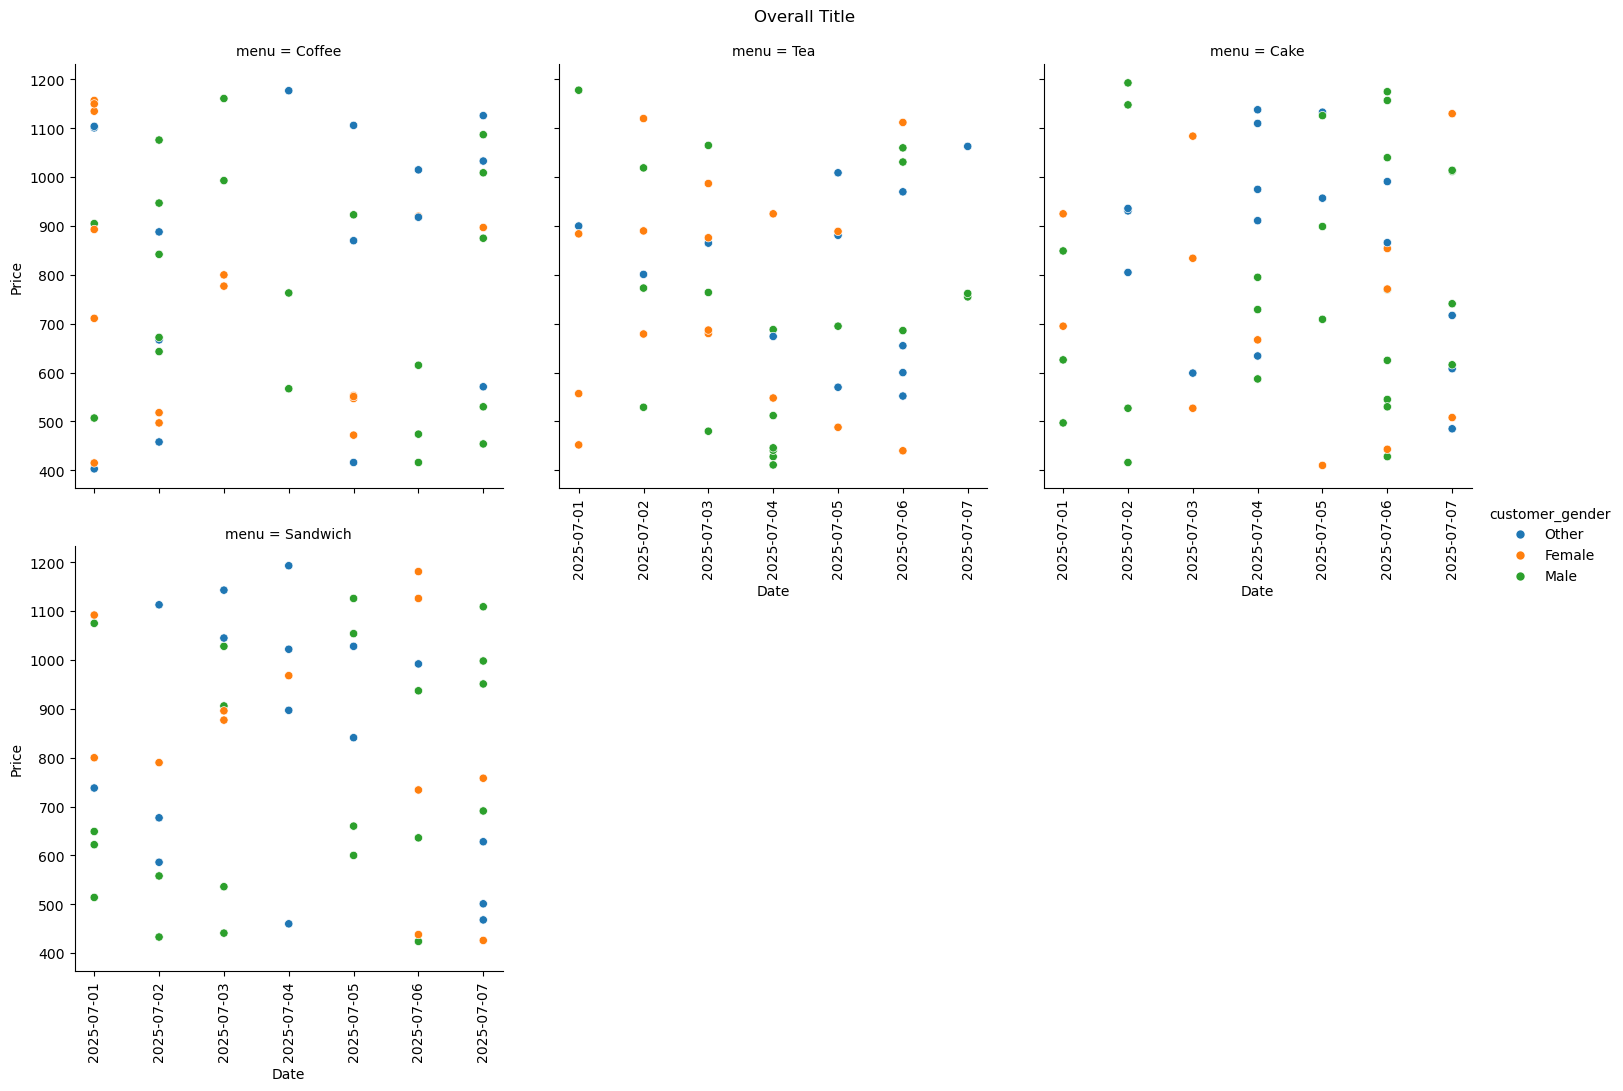

In [16]:
# 内部で勝手に「座席（FigureとAxes）」を作るから、plt.subplots()は不要
g = sns.relplot(data=df, x="date", y="price", hue="customer_gender", kind="scatter", # palette="Pastel1", 
                col="menu", col_wrap=3)

g.fig.suptitle("Overall Title", y=1.02) # Figure全体にタイトル
g.set_axis_labels("Date", "Price")      # 全グラフの軸ラベルを一括設定
# g._legend.set_title("Menu")             # 凡例のタイトル変更
# すべてのaxesに対して、x軸の目盛りの角度を設定
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=90)
plt.show()  

## axis-levelで複数グラフ

### plt.subplots
- axes[行, 列] で直感的
- ループ処理にも向いてる
- fig（外枠）と axes（中身の箱）を最初に一括で作るから、サイズ感やレイアウトの調整が一度に済む

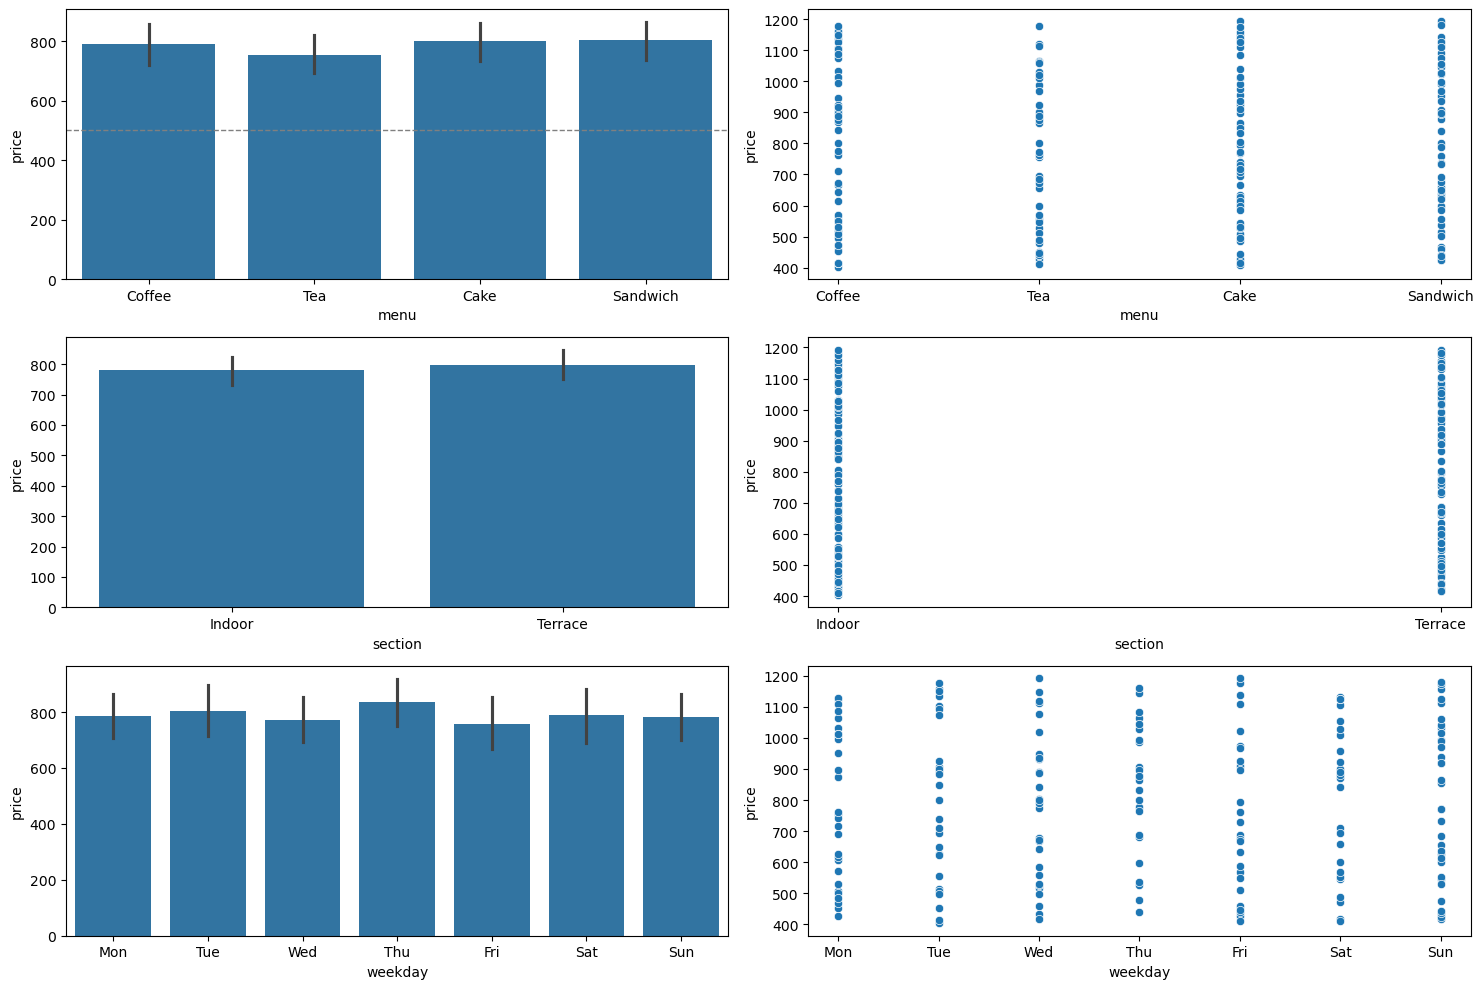

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10)) # 3行2列のグリッドでaxesを作成

# plt.subplotsで複数のaxesもらった時は、numpy配列として並んでる。インデックスで場所を指定する
sns.barplot(data=df, x="menu", y="price", ax=axes[0, 0])  # 1行1列目のaxesにプロット
# axes[0, 0].hlines(xmin=base_date, xmax=df_diag_control['std_resid'].max(), y=mean_post, color="gray", linestyles="dashed", linewidth=1)
axes[0, 0].axhline(500, color="gray", linestyle="dashed", linewidth=1)

sns.scatterplot(data=df, x="menu", y="price", ax=axes[0, 1])  # 1行2列目のaxesにプロット

sns.barplot(data=df, x="section", y="price", ax=axes[1, 0])  # 2行1列目のaxesにプロット
sns.scatterplot(data=df, x="section", y="price", ax=axes[1, 1])  # 2行2列目のaxesにプロット
sns.barplot(data=df, x="weekday", y="price", ax=axes[2, 0]) # 3行1列目のaxesにプロット
sns.scatterplot(data=df, x="weekday", y="price", ax=axes[2, 1])  # 3行2列目のaxesにプロット
plt.tight_layout()
plt.show()


# # 3行1列の時は
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15)) # 3行1列のグリッドでaxesを作成
# axes[0].plot(df["date"], df["value"]) # 1行目のaxesにプロット
# axes[1].plot(df["date"], df["value"]) # 2行目のaxesにプロット
# axes[2].plot(df["date"], df["value"]) # 3行目のaxesにプロット
# plt.tight_layout
# plt.show()


# # 1こだけなら
# # これでもいいんだが
# fig, ax = plt.subplots(figsize=(10, 5)) # 1行1列のグリッドでaxesを作成

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5)) # 1行1列のグリッドでaxesを作成
# ax.plot(df["date"], df["value"]) # axにプロット
# plt.tight_layout
# plt.show()

In [ ]:
# fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))で
# 5個だけ描画するときには、6番目のaxesを非表示にするなら、
axes[2, 1].axis('off')

### fig.add_subplot
- 不規則なレイアウト: 「1行目は1つだけ大きく、2行目は3つ並べたい」みたいに、格子状じゃない変則的な配置をしたいとき。
- 動的な追加: 途中の計算結果を見てから、「あ、やっぱりもう一個グラフを追加しよう」と後出しで箱を作るとき。

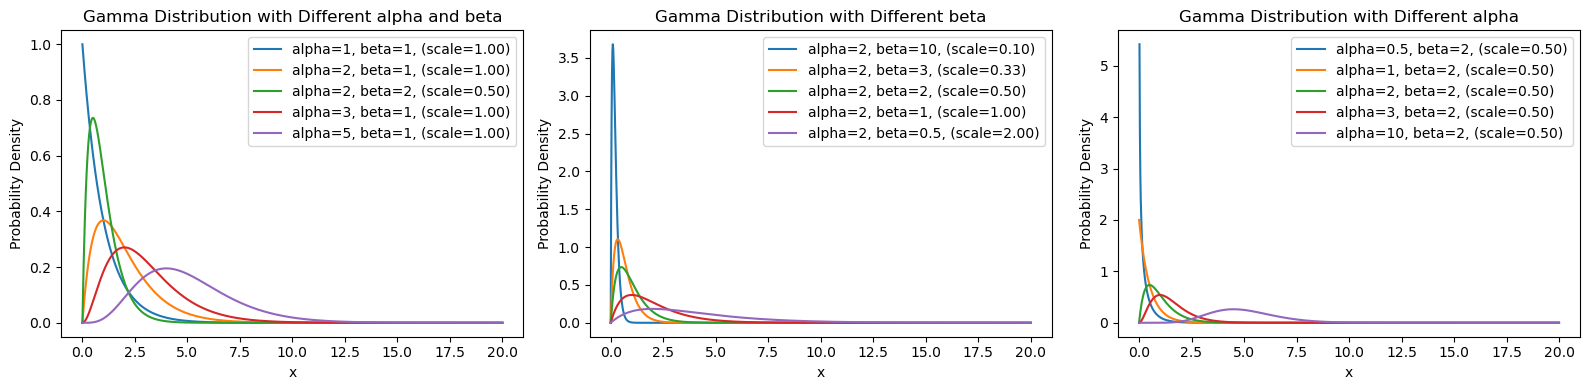

In [18]:
# axis-levelで複数グラフを描画するときに、複雑なグラフだと上の書き方だと大変な場合もある

fig = plt.figure(figsize=(16, 4))

# 1行3列のうち1コめ
ax1 = fig.add_subplot(131)
# ガンマ分布がいまいちイメージしきれないのでいろいろなパラメータでプロットしてみる
from scipy.stats import gamma
# パラメータのリストを定義
params = [
    {'alpha':1, 'beta': 1},
    {'alpha':2, 'beta': 1},
    {'alpha':2, 'beta': 2},
    {'alpha':3, 'beta': 1},
    {'alpha':5, 'beta': 1},
    ]

# プロット用のx軸の値を生成
x = np. linspace(0, 20, 1000)
# 各パラメータセットについてガンマ分布をプロット
for param in params:
  alpha = param['alpha']
  beta = param['beta']
  current_scale = 1/beta  # scipyのガンマ分布は尺度パラメータが1/beta
  y=gamma.pdf(x, a=alpha, scale=current_scale)
  plt.plot(x, y, label=f'alpha={alpha}, beta={beta}, (scale={current_scale:.2f})')

ax1.set_title("Gamma Distribution with Different alpha and beta")
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.legend()


ax2 = fig.add_subplot(132)
alpha = 2  # 固定のalpha値
beta_values = [10, 3, 2, 1, 0.5]  # betaの異なる値
# プロット用のx軸の値を生成
x = np.linspace(0, 20, 1000)
# 各beta値についてガンマ分布をプロット
for beta in beta_values:
  current_scale = 1/beta  # scipyのガンマ分布は尺度パラメータが1/beta
  y=gamma.pdf(x, a=alpha, scale=current_scale)
  plt.plot(x, y, label=f'alpha={alpha}, beta={beta}, (scale={current_scale:.2f})')

ax2.set_title('Gamma Distribution with Different beta')
ax2.set_xlabel('x')
ax2.set_ylabel ('Probability Density')
ax2.legend()


ax3 = fig.add_subplot (133)
alpha_values = [0.5, 1, 2, 3, 10]  # alphaの異なる値
beta = 2  # 固定のbeta値
# プロット用のx軸の値を生成
x = np.linspace(0, 20, 1000)
# 各alpha値についてガンマ分布をプロット
for alpha in alpha_values:
  current_scale = 1/beta  # scipyのガンマ分布は尺度パラメータが1/beta
  y=gamma.pdf(x, a=alpha, scale=current_scale)
  plt.plot(x, y, label=f'alpha={alpha}, beta={beta}, (scale={current_scale:.2f})')

ax3.set_title('Gamma Distribution with Different alpha')
ax3.set_xlabel('x')
ax3.set_ylabel ('Probability Density')
ax3.legend()

plt.tight_layout()
plt.show()

# displot
- 分布を可視化。distributionの略

## hist

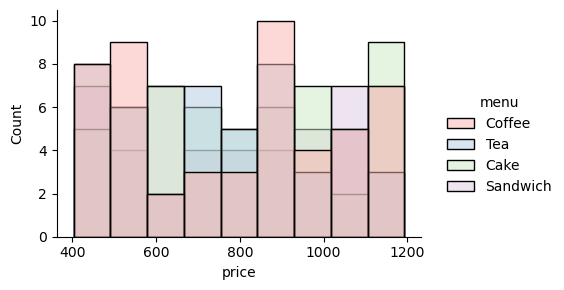

In [17]:
sns.displot(data=df, x="price", hue="menu", kind="hist", palette="Pastel1", aspect=1.5, height=3)
plt.show()

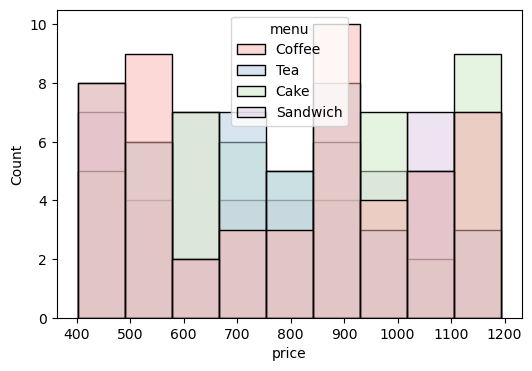

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="price", hue="menu", palette="Pastel1")

# hueで数が違ってて、割合で見たい時は
# sns.histplot(data=df, x="price", hue="menu", palette="Pastel1", stat="percent", multiple="stack")

plt.show()

## 離散値をbins指定でplot

In [ ]:
plt.figure(figsize=(9, 4))

# histogramだけ見たいとき用
# sns.histplot(customer_counts, bins=50, kde=False, color="royalblue")

# histogramとKDE曲線を同時に見たいとき用
# sns.histplot(customer_counts, bins=50, kde=True, color="royalblue", stat="density")

# 離散値(出現回数)のヒストグラムをbins指定でplotする際の注意点
# このデータの場合、min1 max74なので、bins=50にすると、1刻みの整数で区切られずに、74/50=1.48刻みのbinになる。
# 第1bin（幅 0 〜 1.48）: 出現回数1の「1つだけ」が含まれる。
# 第2bin（幅 1.48 〜 2.96）: 出現回数2の「1つだけ」が含まれる。
# 第3bin（幅 2.96 〜 4.44）: 出現回数3と4の「2つ分」がまとめて放り込まれる（件数が2倍のぶん突起する）
# といったことが起きてhistogramが意味ありげな規則的でギザギザに見えてしまう場合がある。
# binsの設定次第では、1本の棒がカバーする幅（74÷bins）がちょうど1刻みの整数と合うことで、ギザギザが出現しない場合もある

# 回避策
# 最小値から最大値まで、1刻みの整数でbinを固定する（binには数値だけでなく配列を直接渡すこともできる）
# sns.histplot(customer_counts, bins=range(1, customer_counts.max() + 2), kde=True, color="royalblue", stat="density")
sns.histplot(customer_counts, bins=range(1, customer_counts.max() + 2), kde=False, color="royalblue")


# xがもっと多い（幅がある）とき用
# bins（個数）ではなく、binwidth（幅）を5や10に固定する
# sns.histplot(customer_counts, binwidth=5, kde=True, color="royalblue", stat="density")

# ロングテールで見づらいとき用
# 対数スケール（log_scale=True）にする（対数的にキリのいい幅で等比級数的にbinを区切ってくれる）
# sns.histplot(customer_counts, log_scale=True, kde=True, color="royalblue", stat="density")

# plt.title("顧客別アプリログ出現回数の分布（ヒストグラム × KDE）")
# plt.xlabel("出現回数（91日間のログ行数）")
# plt.ylabel("密度（Density）")
plt.xlabel('Number of Occurrences per Customer')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## kde

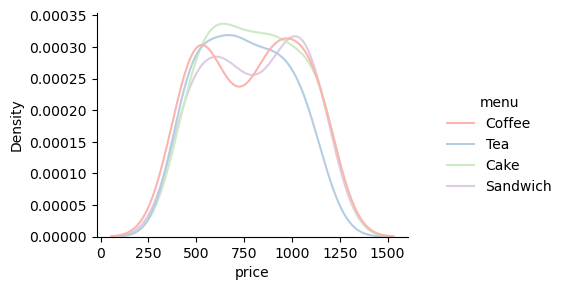

In [19]:
sns.displot(data=df, x="price", hue="menu", kind="kde", palette="Pastel1", aspect=1.5, height=3)
plt.show()

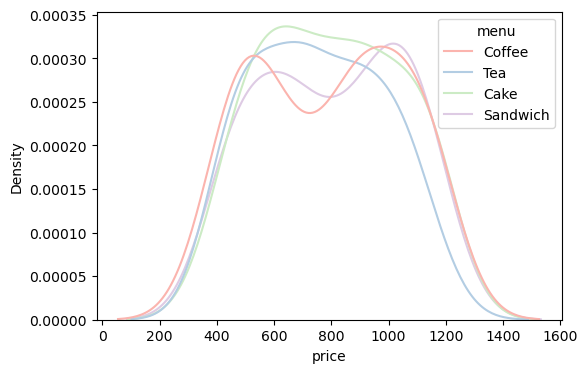

In [20]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="price", hue="menu", palette="Pastel1")
plt.show()


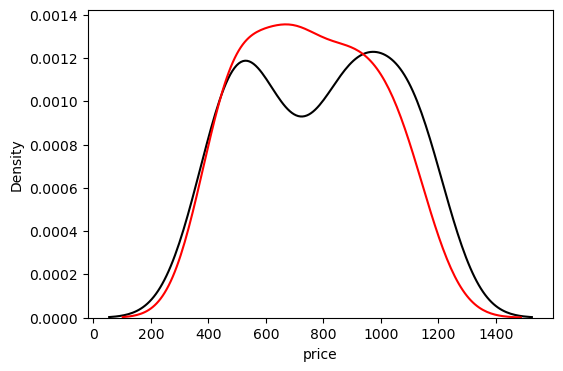

In [21]:
# hue別の数が違う時は個別のkdeplotを重ねる
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df[df["menu"]=="Coffee"], x="price", color="black", label="Coffee")
sns.kdeplot(data=df[df["menu"]=="Tea"], x="price", color="red", label="Tea")
plt.show()

## ecdf 累積分布

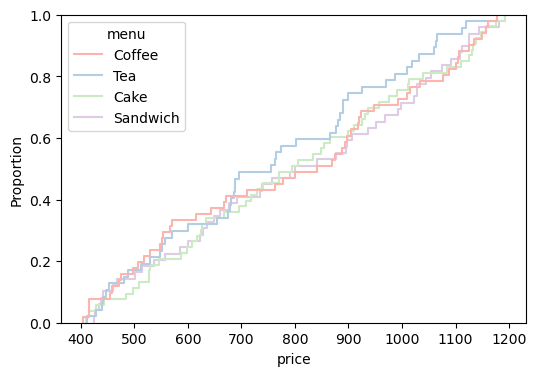

In [22]:
plt.figure(figsize=(6, 4))
sns.ecdfplot(data=df, x="price", hue="menu", palette="Pastel1")
plt.show()

## rug
- データがどの位置にどれだけ集中してるかを視覚的に見せる。単体では出番ないかも

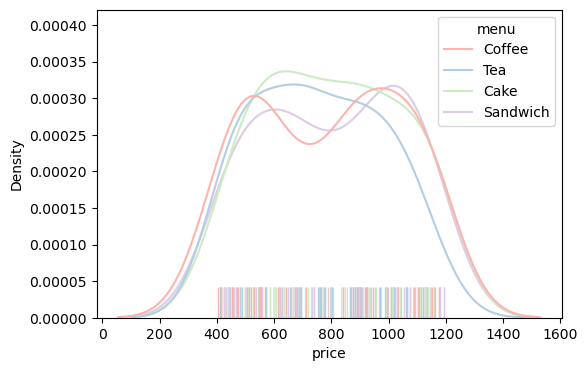

In [23]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="price", hue="menu", palette="Pastel1")
sns.rugplot(data=df, x="price", hue="menu", palette="Pastel1", height=0.1)
plt.show()

# relplot
- 数量データ同士の関係性を可視化。relationの略

## scatter

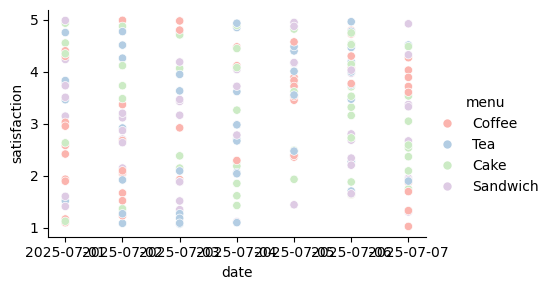

In [24]:
sns.relplot(data=df, x="date", y="satisfaction", hue="menu", palette="Pastel1", kind="scatter", aspect=1.5, height=3)
plt.show()

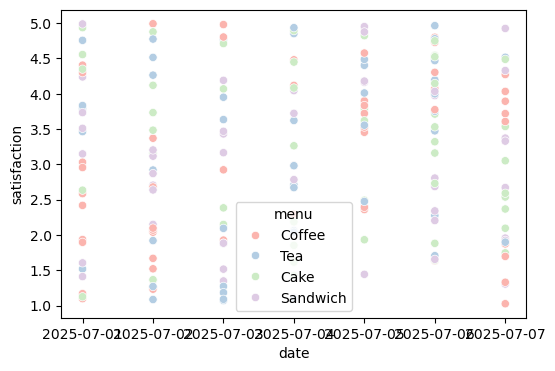

In [25]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="date", y="satisfaction", hue="menu", palette="Pastel1")
plt.show()

## line

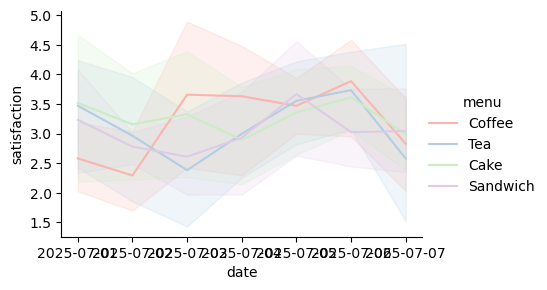

In [26]:
sns.relplot(data=df, x="date", y="satisfaction", hue="menu", palette="Pastel1", kind="line", aspect=1.5, height=3)
plt.show()

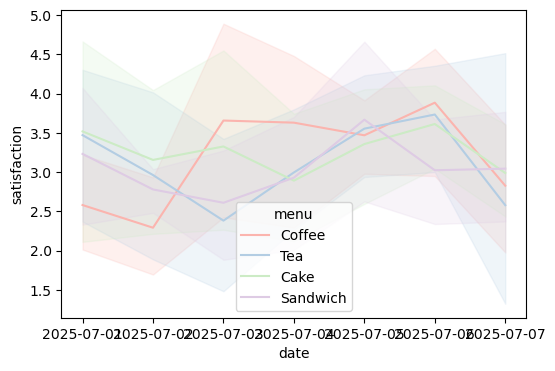

In [27]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=df, x="date", y="satisfaction", hue="menu", palette="Pastel1")
plt.show()

# lineplot mean,medianを横に線で繋げる分、時点推移っぽい見栄え。塗りつぶしで95%ciもつけることができる
# barplot mean,medianが棒で目立ちやすい。95%ciは添え物扱い
# pointplot mean,medianが点で控えめ、95%ciの不確かさが表現しやすい linestyle="none"全体だが。表示することで時点推移にも使える

## scatter + line like DID

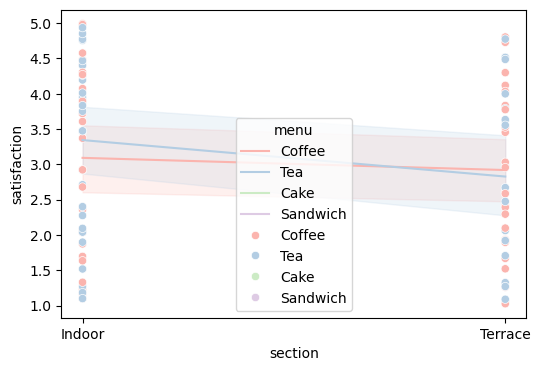

In [28]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=df.query('menu in ("Coffee", "Tea")'), x="section", y="satisfaction", hue="menu", palette="Pastel1")
sns.scatterplot(data=df.query('menu in ("Coffee", "Tea")'), x="section", y="satisfaction", hue="menu", palette="Pastel1")
plt.show()

# catplot
- categoricalデータなどを可視化

## bar

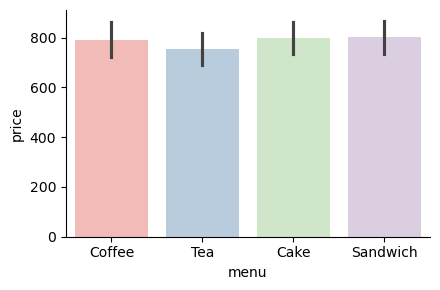

In [29]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="bar", aspect=1.5, height=3)
plt.show()

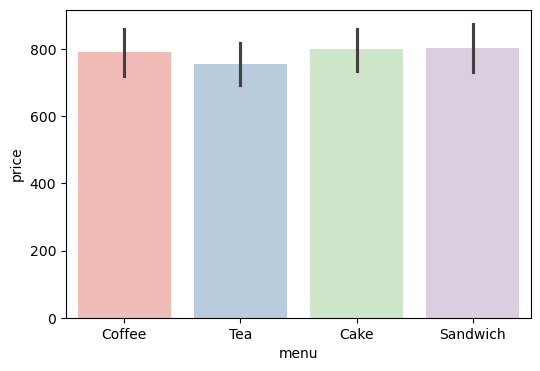

In [30]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1")
plt.show()

## 積み上げ棒グラフ

## box
- 四分位範囲や外れ値を強調しやすい
- シンプルで解釈が容易なため、データの要約統計量を迅速に伝えるのに適している

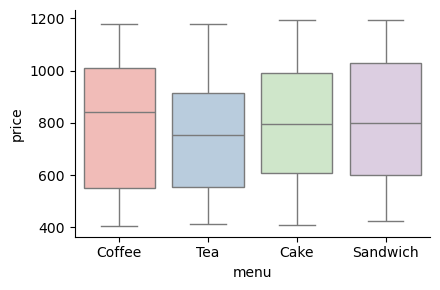

In [31]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="box", aspect=1.5, height=3)
plt.show()

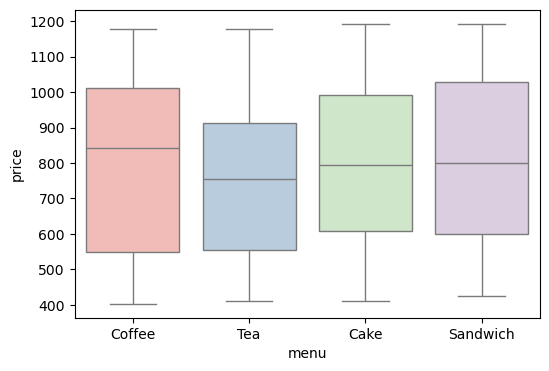

In [32]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1")
plt.show()

## violin
- データの分布や形状をカーテル密度推定を用いて表示
- 分布の広がり（幅が広いとデータが密集してて、狭いとデータが少ない）、多峰性や分布のピークが伝わりやすい
- データの分布の全体感が視覚的にわかりやすい

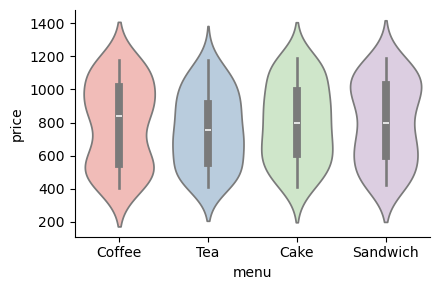

In [33]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="violin", aspect=1.5, height=3)
plt.show()

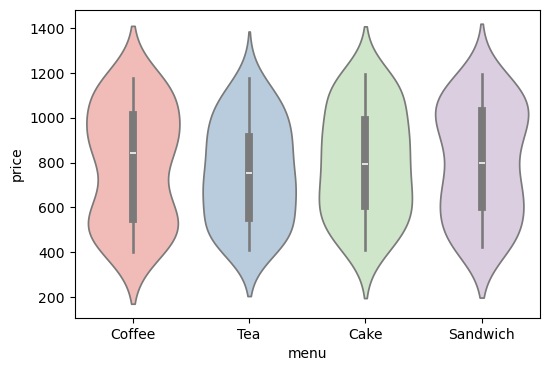

In [34]:
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1")
plt.show()

## strip
- プロットが重なって表示される（ので適度に間引かれる）
- jitter=Trueで横方向に散らすと（jitter=0.2など数値指定も可能）、データの密集度がわかりやすい

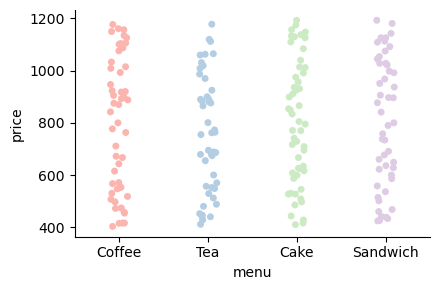

In [35]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="strip", aspect=1.5, height=3)
plt.show()

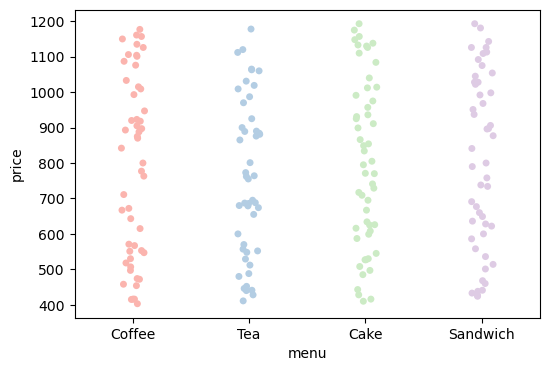

In [36]:
plt.figure(figsize=(6, 4))
sns.stripplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1")
plt.show()

## swarm
- プロットが重ならないように配置される

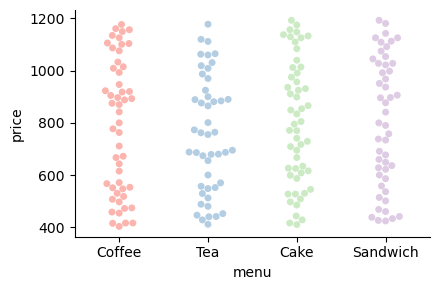

In [37]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="swarm", aspect=1.5, height=3)
plt.show()

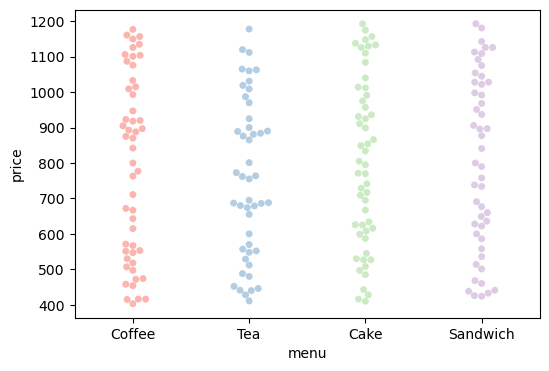

In [38]:
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1")
plt.show()

## point
- mean&95%ciに向いてそう

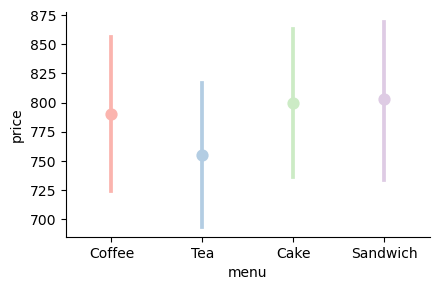

In [39]:
sns.catplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", kind="point",aspect=1.5, height=3)
plt.show()

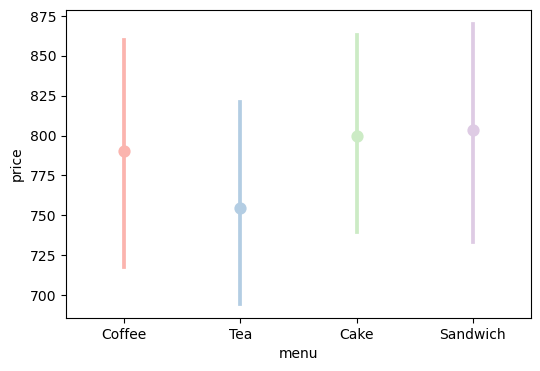

In [40]:
plt.figure(figsize=(6, 4))
sns.pointplot(data=df, x="menu", y="price", hue="menu", palette="Pastel1", 
              # errorbar=None
              )
plt.show()

# lmplot, regplot
- 回帰分析の可視化的な

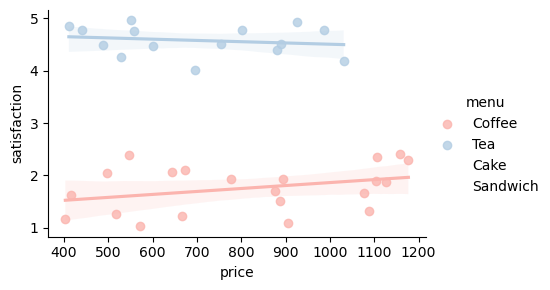

In [41]:
sns.lmplot(data=df.query('(menu=="Coffee" & satisfaction<=2.5) | (menu=="Tea" & satisfaction>=4)'), x="price", y="satisfaction", hue="menu", palette="Pastel1", aspect=1.5, height=3,
        #    ci=None
           )
plt.show()

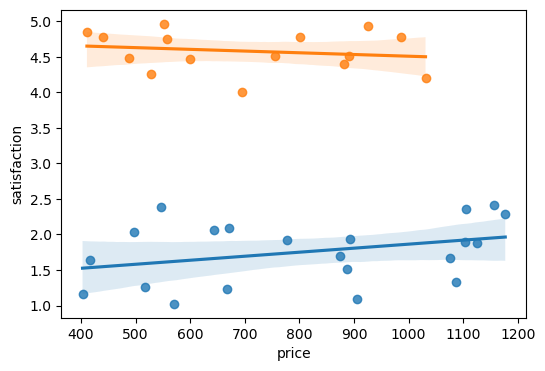

In [42]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df.query('menu=="Coffee" & satisfaction<=2.5'), x="price", y="satisfaction")
sns.regplot(data=df.query('menu=="Tea" & satisfaction>=4'), x="price", y="satisfaction")
plt.show()
# hueは使えないが、重ねて描画することはできる

# pairplot
- データセットに含まれる全ての数量データの組み合わせを散布図行列で可視化

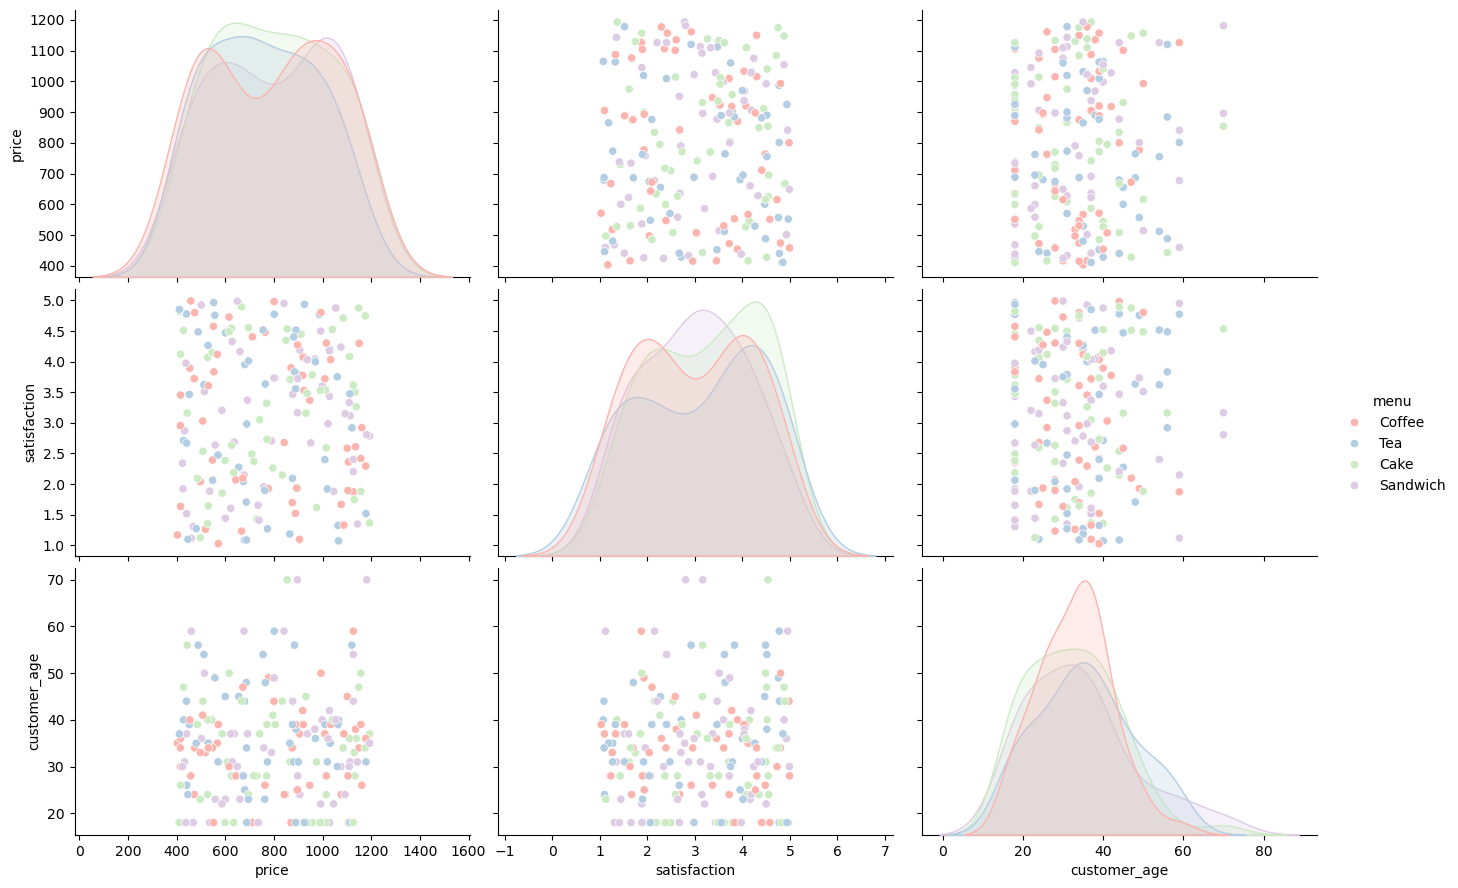

In [43]:
sns.pairplot(data=df, hue="menu", palette="Pastel1", aspect=1.5, height=3)
plt.show()

# jointplot
- 2つの数量データの関係を詳細に可視化

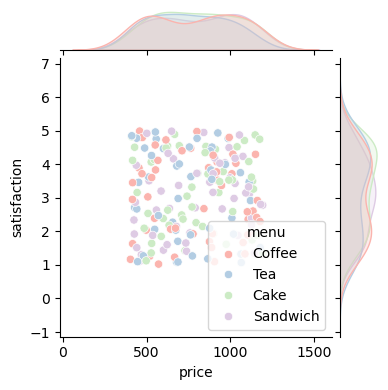

In [44]:
sns.jointplot(data=df, x="price", y="satisfaction", hue="menu", palette="Pastel1",
              height=4,      # 全体の高さをインチで指定（デフォルトは6）
              ratio=6,       # メイン図と端の図の比率（大きいほどメインが広くなる）
              space=0.2      # メイン図と端の図の隙間)
              )
plt.show()
# aspect設定はない。正方形で出力する前提なので

# clustermap
- 行列をクラスタリングで並べ替えたヒートマップ
- 行や列の似ているもの同士を近くに並べてみせる

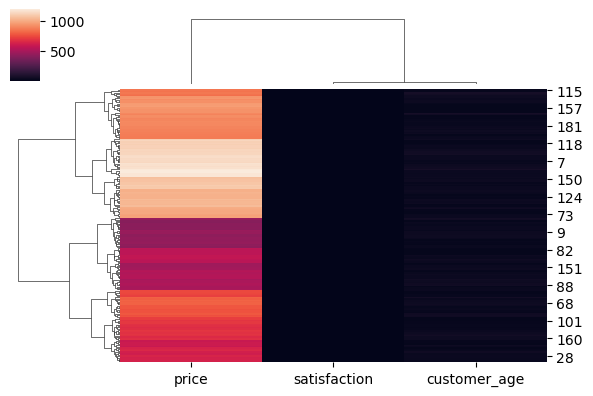

In [45]:
# オブジェクトを含むdataframeをそのまま渡してもエラーになるので
# 数値型（int, float）の列だけを自動的にピックアップして渡す
sns.clustermap(df.select_dtypes(include=[np.number]), figsize=(6, 4))
plt.show()
# ただしこれだと、右端がindexで表示されるため、どれが誰かはパットはわかりにくい

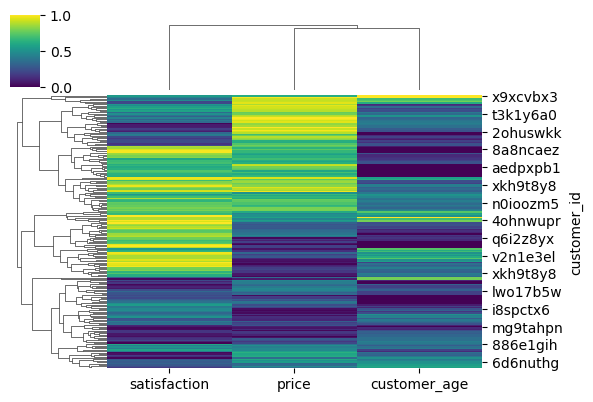

In [46]:
# customer_idをインデックスにして、数値列だけを抽出しておいて
df_numeric = df.set_index('customer_id').select_dtypes(include=[np.number])

sns.clustermap(df_numeric, cmap='viridis', standard_scale=1, figsize=(6, 4))
plt.show()
# これだと右端がcustomer_id表示になる。だが200レコードならサクッとできるがヒト単位で見たいことはそうないだろうから

In [47]:
# 数値データだけを抽出しつつ、menuで集約したmeanにしておいて
df_cluster = df.groupby('menu', observed=True).mean(numeric_only=True)

In [48]:
df_cluster

,price,satisfaction,customer_age
menu,,,
Coffee,790.294118,3.007210,32.960784
Tea,754.829787,3.123825,35.531915
Cake,799.962264,3.265479,32.547170
Sandwich,803.387755,3.029765,34.204082


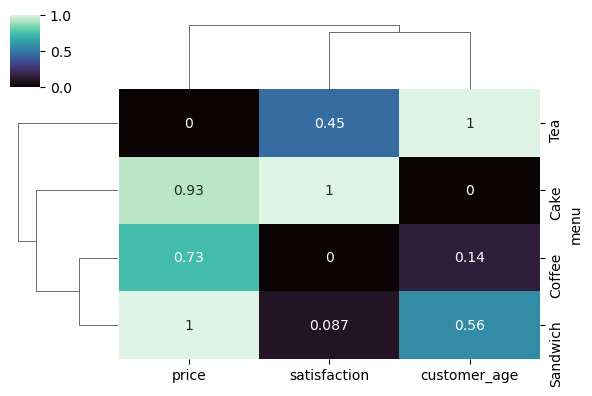

In [49]:
sns.clustermap(
    df_cluster,
    figsize=(6, 4),      # サイズ（比率）を指定(横8インチ, 縦5インチ)
    cmap="mako",
    standard_scale=1,    # 単位が違うデータの比較に必須
    annot=True           # 数値を表示する
)
plt.show()

In [50]:
# 1. 色の読み解き（スケーリングされた値）
# standard_scale=1 を使っているから、各列（縦方向）の中で 「最小値が0、最大値が1」 になるように変換されている。
# 1に近い色（薄い緑）: その項目において、他のメニューよりも値が高い。 例：Tea の satisfaction は「1」だから、4つの中で一番満足度が高いことがわかる。
# 0に近い色（黒）: その項目において、値が低い。 例：Tea の customer_age は「0」だから、一番若い客層が頼んでいると言えそう。

# 2. 横の枝分かれ（メニューの類似度）
# 左側にあるトーナメント表みたいな枝（デンドログラム）は、「どのメニュー同士が似た傾向にあるか」 を表している。
# Coffee と Cake: 枝が一番近いところでつながっているよね？これは「客層・価格・満足度のパターンがこの2つは似ている」ってこと。
# Sandwich: その次に Coffee＆Cake の仲間に加わっている。
# Tea: 一番遠いところでつながっているから、他の3つとはちょっと毛色が違う（例えば極端に客層が若いなど）ことが読み取れる。

# 3. 上の枝分かれ（項目の関連性）
# 上の枝は、項目同士の似具合。
# price と satisfaction: 枝が近い。このデータ上では「価格が高いと満足度も高い（あるいはその逆）」といった、似たような動きをしている可能性がある。
# customer_age: それらとは独立して動いているみたいだ。

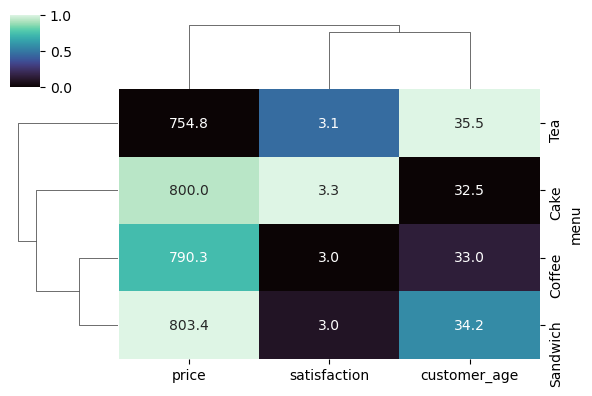

In [51]:
sns.clustermap(
    df_cluster,
    figsize=(6, 4),      # サイズ（比率）を指定(横8インチ, 縦5インチ)
    cmap="mako",
    # fmt="g",  # 「いい感じに（General）」表示してねという指定
    fmt=".1f",  # 強制的に「小数点以下1桁」で揃える
    standard_scale=1,    # 単位が違うデータの比較に必須
    # annot=True           # 数値を表示する。
    annot=df_cluster.values  # ここに元の数値を流し込む
)
plt.show()

# annot=Trueで数値を表示したいときに、standard_scale=1を指定しない状態でやると、色の塗り分けが全部共通になるため、色の解釈がほぼ無理になる
# なのでstandard_scale=1は指定して、annot=df_cluster.valuesで元の数値は表示しつつ、色はそれぞれでの塗り分けになる

# グラフに縦線や横線を入れる

In [ ]:
# 1. グラフ全体を端から端まで「突き抜ける」線
# 軸全体に引きたいとき
# 類	関数	指定する値	意味
# 水平線	plt.axhline()	y	y=0 の位置に、横いっぱいの線を引く。
# 垂直線	plt.axvline()	x	x=5 の位置に、縦いっぱいの線を引く。
axes[1, 0].axhline(0, color="gray", linestyle="dashed", linewidth=1)
axes[0, 0].axvline(base_date, color="gray", linestyle="dashed", linewidth=1)
axes[0, 0].axhline(0, color="black", linestyle="dashed", linewidth=1)

# 2. 特定の範囲だけ「短く」引く線
# 「ここからここまで」と長さを指定したいとき
# 種類	関数	指定する値（全部必須！）
# 水平線	plt.hlines()	y, xmin, xmax
# 垂直線	plt.vlines()	x, ymin, ymax
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df1_daily_test['date'].max(), y=mean_post, color="red", linestyles="dotted", linewidth=1.5, label="mean_post")

axes[0, 0].vlines(x=base_date, ymin=df_diag_control['std_resid'].min(), ymax=df_diag_control['std_resid'].max(), colors="gray", linestyles="dashed", linewidth=1)

axes[0, 0].hlines(y=0, xmin=df_diag['date'].min(), xmax=df_diag['date'].max(), colors="black", linestyles="dashed", linewidth=1)

# scatterplotにラベルを

# バブルチャートのとか

# water fall chart

# ステップチャート　階段チャート

# 信頼区間の間を塗りつぶしたり